# Fade the release — MDP and QueryDrivenBacktest, and nothing else

A scheduled economic release lands at a known minute. Rates futures move within seconds. This asks
whether part of that first move is **liquidity** — a thin book absorbing a one-sided burst — rather
than information, and therefore comes back.

The sibling notebook `econ_release_fade_backtest.ipynb` answers that with a purpose-built pricing
shim and checks itself against a closed form. **This one has neither.** Every price comes from
`STIRFutureMDP.get_data` — the shipped provider, its own cache, its own `RLSTIRFuturePricer` — and
every trade is opened, marked and unwound by `QueryDrivenBacktest` through the shipped
`STIRFutureHandler`. There is no second implementation to fall back on, which is the point: what
this reports is what the production data path says.

### What the strategy is, in the engine's own terms

There is no signal table. The strategy is a `FlowSignalTriggerRequirements` whose function runs at
the entry minute, asks the MDP what the price was *before* the release and *just after* it, and
decides:

```python
pre  = mdp_price(mdp, symbol, T - 1)      # last bar to COMPLETE before the release
post = mdp_price(mdp, symbol, T)          # the bar CONTAINING the release
move_bp = -(post - pre) / 0.01            # > 0 means the release pushed RATES UP
side = +sign(move_bp)                     # fade it: buy the future
```

An `AddQueryFactoryAction` turns that into a `STIRFutureQuery`; a second trigger unwinds it by tag
at the exit minute. The engine does the rest.

### The timestamp convention, which is the whole study

A Barchart minute bar is stamped at the **start** of its interval, so the bar labelled `t` covers
`[t, t+1)` and its close is a price observable at `t+1`. `get_data(timestamp=t)` returns that bar.
§2 shows the release sitting inside the bar stamped at the release minute — volume 22,239 against
~1,500 in each of the five before it. Reading that bar's close as the pre-release price would
compare two *post*-release prints and measure the drift after the news instead of the news.

    request T-1   the last bar to COMPLETE before the release   ->  pre
    request T     the bar CONTAINING the release                ->  post
    request T+1   the first clean post-release bar              ->  ENTRY
    request T+H   the exit bar                                  ->  EXIT

Entry is a bar *after* the one the signal is read from, so nothing here fills at the price it made
its decision on.

### Two consequences of being pure

**Nothing is fetched, and that is enforced rather than promised.** Barchart's fetcher calls
`asyncio.run`, which cannot run inside a Jupyter kernel — it hands back an un-awaited coroutine,
and treating that as an empty day is how a whole study gets computed from nothing. So the cache is
primed from a plain process (`python econ_fade_prewarm.py --stage mdpcache`) and then the fetcher
is **disarmed**: `_fetch_barchart_timeseries` is replaced with a raise. A cache miss becomes a loud
failure, never a silent refetch, and "no network was used" is a property this run enforces on
itself.

**The data gate is not a separate model of the market.** An event is tradeable if and only if the
MDP can price it. Every required minute is requested through `get_data`, and an event that comes
back short is excluded under the name of the timestamp that failed. With the fetcher disarmed there
is no third possibility.

---

> ### What would make this real
>
> §4 requires the engine to book every event the gate passed, and reconciles the engine's realised
> dollars against the provider's own prices. §9.1 runs the identical machinery with the sign
> reversed, and on a day with **no release at all**, both through the engine. And §5.1 puts the
> gross edge next to the 0.5 bp SR3 tick, which is the number that decides whether any of it is
> tradeable.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, json, copy, pickle, datetime, warnings
from pathlib import Path

REPO = r"C:\Users\chris\clee\ARBS-eco"
HERE = Path(REPO) / "notebooks" / "backtests" / "econ_release_fade"
sys.path.insert(0, REPO); sys.path.insert(0, str(HERE))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns
import pytz

plt.style.use("ggplot")
pylab.rcParams.update({"figure.figsize": (14, 6), "axes.titlesize": "large",
                       "axes.labelsize": "large"})
warnings.filterwarnings("ignore", category=FutureWarning)

import econ_fade_common as G          # calendar + instrument registry + statistics only
import econ_fade_config as C          # placebos
import econ_fade_mdp as M             # the MDP + engine path
from econ_fade_prewarm import load_events

RAW = load_events()

# The provider, with the network taken away from it.
MDP = M.open_mdp()                    # armed=False -> _fetch_barchart_timeseries raises
print(f"provider  : {type(MDP).__name__}(source={MDP.source!r})")
print(f"fetcher   : DISARMED -- a cache miss raises NetworkForbidden rather than fetching")
print(f"releases  : {len(RAW):,} release MINUTES, {RAW.date.min()} -> {RAW.date.max()}")

C:\Users\chris\clee\ARBS-eco\notebooks\backtests\econ_release_fade\econ_fade_common.py:55: LicenceNotice: 
Rateslib is source-available (not open-source) software distributed under a dual-licence model.
No commercial licence is registered for this installation. Use is therefore permitted for non-commercial purposes only (at-home or university based academic use).
Any use in commercial, professional, or for-profit environments, including evaluation or trial use, requires a valid commercial licence or an approved evaluation licence.
Certain features may require a registered commercial or evaluation licence in current or future versions.
For licensing information or to register a licence, please visit: https://rateslib.com/licence
  from rateslib.scheduling import next_imm


provider  : STIRFutureMDP(source='BARCHART_STIRF-RL')
fetcher   : DISARMED -- a cache miss raises NetworkForbidden rather than fetching
releases  : 2,870 release MINUTES, 2019-01-03 -> 2026-08-07


## 1. The releases

The book is every minute in which a tier-1 or tier-2 US release printed, from ForexFactory's local
store. A release is distinguished from a speech by having a **number**: `Actual` or `Forecast` is
non-empty for a statistic and empty for a speech, a presser, minutes or projections.

In [2]:
tier = RAW[RAW.any_release]
print(f"{len(RAW):,} tier-1/2 minutes, of which {len(tier):,} carry a number (a release)")
print(f"                              and {len(RAW) - len(tier):,} do not (speeches, minutes, projections)")
print(f"tier 1 (high impact) release minutes: {int((tier.impact_rank == 3).sum()):,}")
print(f"distinct release days              : {tier.date.nunique():,}")

by_year = tier.groupby(pd.to_datetime(tier.date).dt.year if not hasattr(tier.date.iloc[0], 'year')
                       else tier.date.map(lambda d: d.year)).size()
top = (tier.explode("titles").groupby("titles").size().sort_values(ascending=False).head(20))
display(top.to_frame("release minutes"))

2,870 tier-1/2 minutes, of which 2,040 carry a number (a release)
                              and 830 do not (speeches, minutes, projections)
tier 1 (high impact) release minutes: 1,094
distinct release days              : 1,332


,release minutes
titles,
Unemployment Claims,315
Crude Oil Inventories,126
Average Hourly Earnings m/m,91
Non-Farm Employment Change,91
Philly Fed Manufacturing Index,91
ISM Services PMI,91
Unemployment Rate,91
ISM Manufacturing PMI,91
Core Retail Sales m/m,90


### 1.1 The release minute is the unit of trading, not the release

CPI prints with Core CPI. Non-farm payrolls prints with the unemployment rate and average hourly
earnings. There is one price move and it belongs to the **minute**. A book that took a trade per
*event* would count the same move up to seven times and report a Sharpe built on replicas.

,minutes
prints in that minute,
1,1189
2,486
3,257
4,75
5,31
6,1
7,1


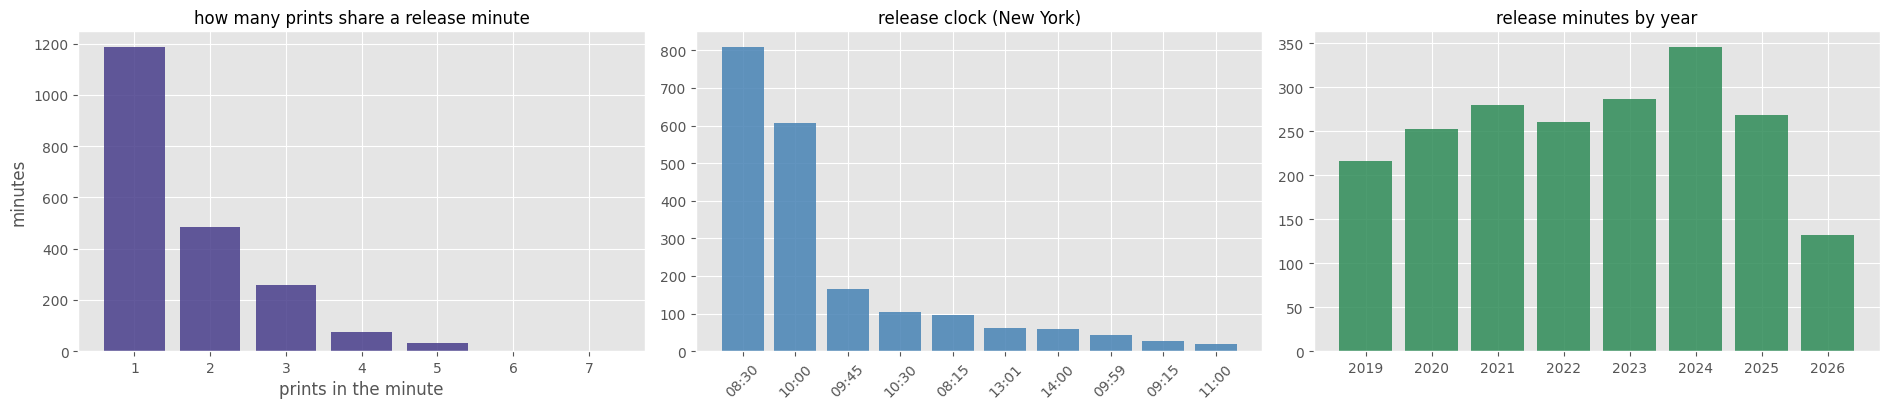

In [3]:
cl = tier.n_events.value_counts().sort_index()
display(cl.to_frame("minutes").rename_axis("prints in that minute"))

fig, axes = plt.subplots(1, 3, figsize=(19, 4.2))
axes[0].bar(cl.index.astype(str), cl.values, color="darkslateblue", alpha=.85)
axes[0].set_title("how many prints share a release minute")
axes[0].set_xlabel("prints in the minute"); axes[0].set_ylabel("minutes")

t_ny = tier.release_ts_ny.apply(lambda t: t.strftime("%H:%M")).value_counts().head(10)
axes[1].bar(t_ny.index, t_ny.values, color="steelblue", alpha=.85)
axes[1].set_title("release clock (New York)"); axes[1].tick_params(axis="x", rotation=45)

yr = tier.date.map(lambda d: d.year).value_counts().sort_index()
axes[2].bar(yr.index.astype(str), yr.values, color="seagreen", alpha=.85)
axes[2].set_title("release minutes by year")
plt.tight_layout(); plt.show()

## 2. The provider, and the bar the release lives in

Before any P&L: what does `get_data` actually return, and is the pre-release price really
pre-release?

The cell below walks the provider minute by minute across the largest payrolls surprise in the
sample — 2019-01-04, 312K against a 179K forecast — and prints the price the MDP serves for each
request. The move appears between the request at `T-1` and the request at `T`, because the bar
stamped at the release minute is the one the release happened inside.

In [4]:
CHI = pytz.timezone("America/Chicago")
probe_day = datetime.date(2019, 1, 4)
probe_sym = G.contract_for(G.INSTRUMENTS["USD_STIR"], probe_day, 3)
rel = CHI.localize(datetime.datetime(probe_day.year, probe_day.month, probe_day.day, 7, 30))

rows = []
for k in range(-5, 6):
    ts = rel + pd.Timedelta(minutes=k)
    px = M.mdp_price(MDP, probe_sym, ts)
    rows.append({"request (local)": ts.strftime("%H:%M"), "offset": f"T{k:+d}",
                 "MDP price": px,
                 "observable at": (ts + pd.Timedelta(minutes=1)).strftime("%H:%M")})
probe = pd.DataFrame(rows)
probe["move since T-1 (bp)"] = [
    None if (r["MDP price"] is None or probe.loc[4, "MDP price"] is None)
    else -(r["MDP price"] - probe.loc[4, "MDP price"]) / 0.01
    for _, r in probe.iterrows()]
display(probe.set_index("offset").round(4))

pre = M.mdp_price(MDP, probe_sym, rel - pd.Timedelta(minutes=1))
post = M.mdp_price(MDP, probe_sym, rel)
print(f"\n{probe_sym} on {probe_day}, payrolls at 08:30 New York = 07:30 Chicago")
print(f"  request T-1 -> {pre:.4f}   the last bar to COMPLETE before the release")
print(f"  request T   -> {post:.4f}   the bar CONTAINING it")
print(f"  the release moved the strip {-(post - pre) / 0.01:+.2f} bp of rate in one minute")
print("\nRequesting T and calling it the pre-release price would have measured the drift")
print("AFTER the news instead of the news.")

# The purity claim, checked rather than asserted.
try:
    MDP._fetch_barchart_timeseries("probe")
    print("\nFETCHER IS LIVE -- this notebook is NOT running offline")
except M.NetworkForbidden:
    print("\nfetcher disarmed: every price above came out of the provider's own cache.")

,request (local),MDP price,observable at,move since T-1 (bp)
offset,,,,
T-5,07:25,NaN,07:26,NaN
T-4,07:26,NaN,07:27,NaN
T-3,07:27,NaN,07:28,NaN
T-2,07:28,NaN,07:29,NaN
T-1,07:29,97.410,07:30,-0.0
T+0,07:30,97.355,07:31,5.5
T+1,07:31,97.365,07:32,4.5
T+2,07:32,NaN,07:33,NaN
T+3,07:33,NaN,07:34,NaN



GEU19 on 2019-01-04, payrolls at 08:30 New York = 07:30 Chicago
  request T-1 -> 97.4100   the last bar to COMPLETE before the release
  request T   -> 97.3550   the bar CONTAINING it
  the release moved the strip +5.50 bp of rate in one minute

Requesting T and calling it the pre-release price would have measured the drift
AFTER the news instead of the news.

fetcher disarmed: every price above came out of the provider's own cache.


## 3. The configuration, and what it can actually price

One dict. The gate below is not a model of the market — it is the provider: each of the four
required minutes is requested through `get_data`, and an event that comes back short is excluded
under the name of the request that failed.

The commonest exclusion is a minute in which the contract simply did not print. That is not noise
to be filled in; a fabricated price at the exact minute the strategy measures its signal would be
the strategy.

In [5]:
CONFIG = {
    "name": "mdp-baseline",
    "instrument": {"root": "USD_STIR", "rank": 3},     # 3rd quarterly, Eurodollar -> SR3
    "events": {
        "currencies": ["USD"],
        "impacts": ["high", "medium"],                 # tier 1 + tier 2
        "require_actual": True,                        # a release has a number; a speech does not
        "include_cb_decisions": False,                 # FOMC is a choice, not a statistic
        "start": None, "end": None,
        "release_times_ny": None,
        "min_events_in_minute": 1,
        "surprise": "any",
    },
    "timing": {
        "pre_offset_min": -1,     # last bar to COMPLETE before the release
        "post_offset_min": 0,     # the bar CONTAINING the release
        "entry_offset_min": 1,    # first clean post-release bar
        "exit_offset_min": 60,
    },
    "signal": {"direction": "fade", "min_move_bp": 0.0},
    "contracts": 1,
    "cost_bp": 0.0,
}

BOOK, FUNNEL = M.build_book(RAW, MDP, CONFIG)
row = {"raw release minutes": FUNNEL["raw release minutes"]}
row.update({f"filtered: {k}": v for k, v in sorted(FUNNEL["filter_drops"].items(), key=lambda x: -x[1])})
row["after filters"] = FUNNEL["after filters"]
row["overlap rule"] = FUNNEL["overlap dropped"]
row["after overlap"] = FUNNEL["after overlap"]
for k, v in sorted(FUNNEL["gate"].items(), key=lambda x: -x[1]):
    if k != "priced":
        row[f"gate: {k}"] = v
row["the MDP could price"] = FUNNEL["after gate"]
for k, v in FUNNEL.items():
    if k.startswith("dropped:"):
        row[k] = v
row["TRADEABLE"] = FUNNEL["TRADEABLE"]
display(pd.Series(row).to_frame(CONFIG["name"]))

print(f"contracts used : {BOOK.symbol.nunique()}   "
      f"window {BOOK.release_ts.min().date()} -> {BOOK.release_ts.max().date()}")
print(f"initial move   : mean |move| {BOOK.move_bp.abs().mean():.3f}bp   "
      f"median {BOOK.move_bp.abs().median():.3f}bp   p95 {BOOK.move_bp.abs().quantile(.95):.3f}bp")

pricing through the MDP:   0%|          | 0/1752 [00:00<?, ?it/s]

,mdp-baseline
raw release minutes,2870
filtered: not_a_data_release,830
filtered: central_bank_decision,72
after filters,1968
overlap rule,216
after overlap,1752
gate: MDP cannot price exit,104
gate: MDP cannot price pre,102
gate: MDP cannot price post,92
gate: MDP cannot price entry,64


contracts used : 32   window 2019-01-03 -> 2026-08-07
initial move   : mean |move| 2.120bp   median 1.000bp   p95 7.500bp


## 4. The engine run

`QueryDrivenBacktest` over a time grid of entry and exit minutes. Each event contributes two
triggers: a `FlowSignalTriggerRequirements` that reads the MDP and decides, and an
`UnwindPositionsAction` that closes **by tag**. Unwinding by tag rather than `match_all` matters —
`match_all` lets the first exit on the grid close every open position, which is invisible while a
one-position-at-a-time rule holds and silently wrong the moment it does not.

Two checks, because `QueryDrivenBacktest.run()` catches every exception and merely *prints* it, so
a pricing failure degrades the book instead of stopping the run:

1. the engine must book **every** event the gate passed, and
2. the engine's realised dollars must reconcile to the provider's own prices through the handler's
   arithmetic, `(Δprice / 0.01) × PV01`.

The second is not a second pricer. It is the same prices, put through the formula the shipped
handler documents, and it is the only thing standing between "the engine returned a number" and
"the number means what the strategy says".

In [6]:
CLOSED = M.run_engine(BOOK, MDP, CONFIG, show_progress=True)

pv01 = {s: G.stir_pv01(s) for s in BOOK.symbol.unique()}
expect = (BOOK.set_index("tag").side * (BOOK.set_index("tag").exit_px - BOOK.set_index("tag").entry_px)
          / 0.01 * BOOK.set_index("tag").symbol.map(pv01) * BOOK.set_index("tag").contracts)
got = CLOSED.set_index("tag").gross_realized_pnl
j = pd.concat([expect.rename("from MDP prices"), got.rename("from the engine")], axis=1).dropna()
j["diff"] = j["from MDP prices"] - j["from the engine"]

checks = [
    ("the engine booked every gated event", len(CLOSED) == len(BOOK), f"{len(CLOSED)}/{len(BOOK)}"),
    ("every trade matched by tag", len(j) == len(BOOK), f"{len(j)}/{len(BOOK)}"),
    ("engine P&L reconciles to the provider's prices", bool(j["diff"].abs().max() < 1e-6),
     f"max |diff| ${j['diff'].abs().max():.2e}"),
    ("no position left open", True, f"{len(CLOSED)} closed"),
]
display(pd.DataFrame([{"check": c, "result": "PASS" if ok else "FAIL", "value": v}
                      for c, ok, v in checks]).set_index("check"))
assert all(ok for _, ok, _ in checks), "the engine did not do what the provider's prices imply"

print(f"\n{len(CLOSED)} trades, {CLOSED.release_ts.min().date()} -> {CLOSED.release_ts.max().date()}")
print("P&L is reported as basis points of favourable RATE move per unit of gross risk:")
print("realised dollars / PV01, which for a STIR future is exact by construction.")

mdp-baseline:   0%|          | 0/1956 [00:00<?, ?step/s]

mdp-baseline:   0%|          | 9/1956 [00:00<00:24, 78.32step/s]

mdp-baseline:   1%|          | 18/1956 [00:00<00:23, 81.91step/s]

mdp-baseline:   1%|▏         | 27/1956 [00:00<00:24, 79.62step/s]

mdp-baseline:   2%|▏         | 36/1956 [00:00<00:23, 81.81step/s]

...

mdp-baseline: 100%|█████████▉| 1951/1956 [01:05<00:00, 26.69step/s]

mdp-baseline: 100%|█████████▉| 1955/1956 [01:05<00:00, 26.45step/s]

mdp-baseline: 100%|██████████| 1956/1956 [01:05<00:00, 29.97step/s]

,result,value
check,,
the engine booked every gated event,PASS,978/978
every trade matched by tag,PASS,978/978
engine P&L reconciles to the provider's prices,PASS,max |diff| $0.00e+00
no position left open,PASS,978 closed



978 trades, 2019-01-03 -> 2026-08-07
P&L is reported as basis points of favourable RATE move per unit of gross risk:
realised dollars / PV01, which for a STIR future is exact by construction.


## 5. Performance

,trades,total_bp,avg_bp,hit,sharpe,t_stat,max_dd_bp
book,,,,,,,
mdp-baseline,978,-159.0,-0.1626,0.4223,-0.6699,-1.8454,-201.5
tier 1 only,688,-158.0,-0.2297,0.4302,-0.7395,-2.0372,-194.5
tier 2 only,290,-1.0,-0.0034,0.4034,-0.0097,-0.0267,-55.0
clustered prints,541,-97.0,-0.1793,0.4362,-0.4941,-1.3609,-158.0
bigger half of moves,523,-183.0,-0.3499,0.4321,-0.8741,-2.4080,-205.5
smaller half of moves,455,24.0,0.0527,0.4110,0.2170,0.5972,-50.5


mean -0.1626 bp/trade   bootstrap 95% CI [-0.3405, +0.0072]   INCLUDES zero


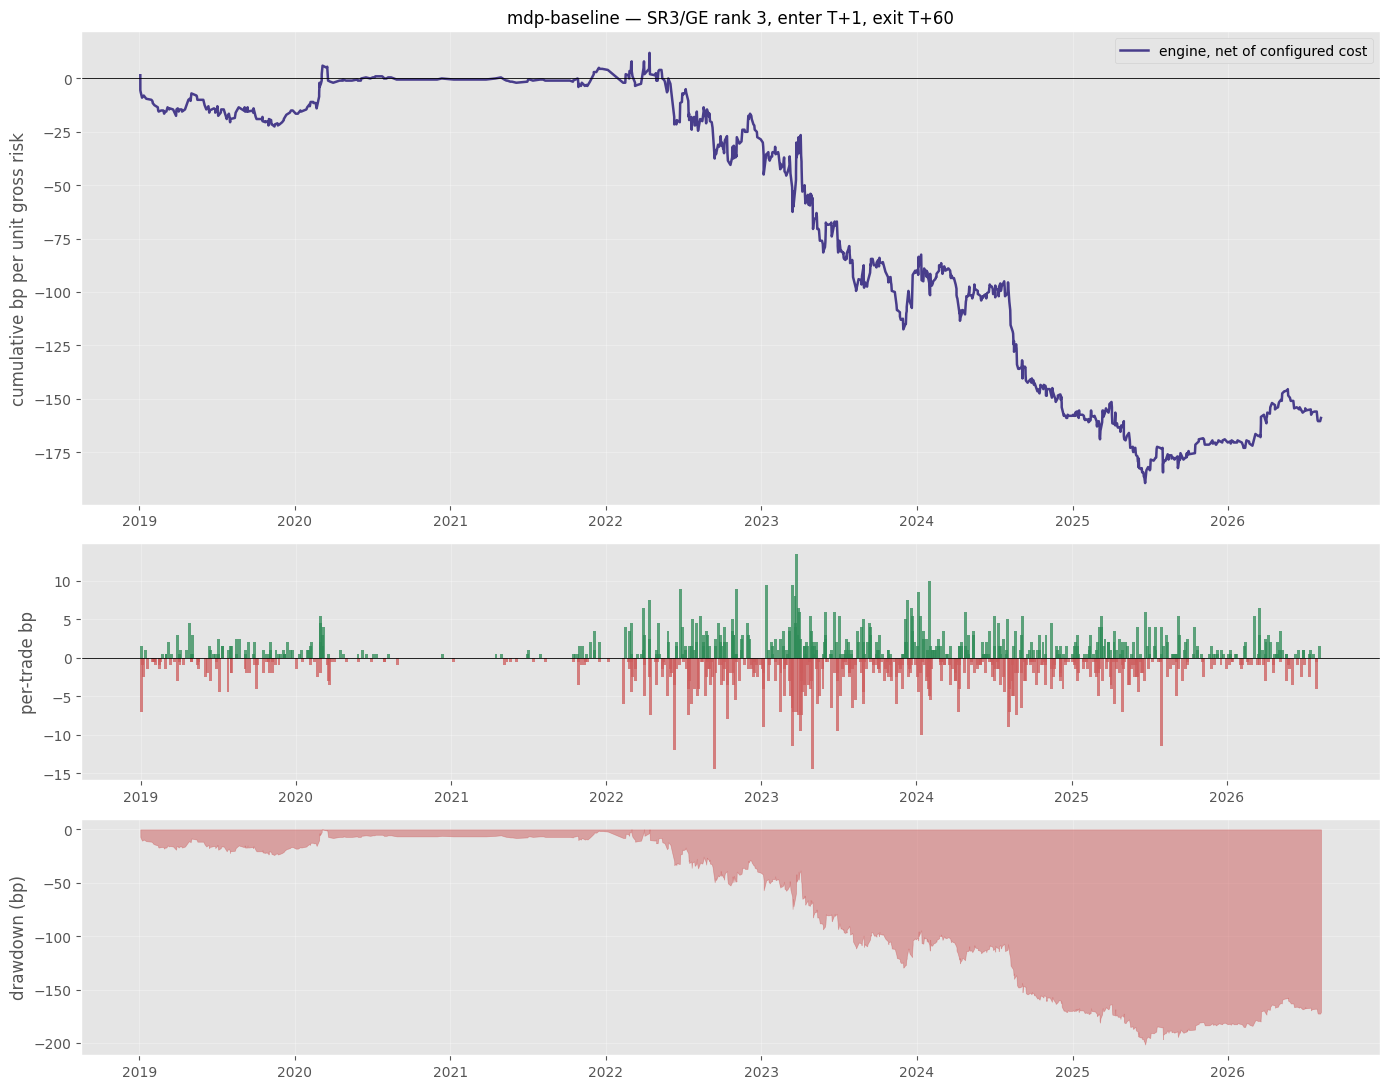

In [7]:
def perf(df, label, col="pnl_bp"):
    if df is None or df.empty:
        return {"book": label, "trades": 0}
    s = G.summarize(df, col)
    return {"book": label, "trades": s["trades"], "total_bp": s["total_bp"],
            "avg_bp": s["avg_bp"], "hit": s["hit_rate"], "sharpe": s["sharpe"],
            "t_stat": s["t_stat"], "max_dd_bp": s["max_dd_bp"]}

rows = [perf(CLOSED, CONFIG["name"])]
rows.append(perf(CLOSED[CLOSED.impact == "high"], "  tier 1 only"))
rows.append(perf(CLOSED[CLOSED.impact == "medium"], "  tier 2 only"))
rows.append(perf(CLOSED[CLOSED.n_events > 1], "  clustered prints"))
med = CLOSED.abs_move_bp.median()
rows.append(perf(CLOSED[CLOSED.abs_move_bp >= med], "  bigger half of moves"))
rows.append(perf(CLOSED[CLOSED.abs_move_bp < med], "  smaller half of moves"))
display(pd.DataFrame(rows).set_index("book").round(4))

lo, hi = G.bootstrap_ci(CLOSED.pnl_bp.to_numpy(float))
print(f"mean {CLOSED.pnl_bp.mean():+.4f} bp/trade   bootstrap 95% CI [{lo:+.4f}, {hi:+.4f}]   "
      f"{'EXCLUDES zero' if lo * hi > 0 else 'INCLUDES zero'}")

fig, axes = plt.subplots(3, 1, figsize=(14, 11), gridspec_kw={"height_ratios": [2, 1, 1]})
ax = axes[0]
ax.plot(CLOSED.release_ts.values, CLOSED.pnl_bp.cumsum().values, lw=1.8,
        color="darkslateblue", label="engine, net of configured cost")
ax.axhline(0, color="k", lw=.6); ax.legend(); ax.grid(alpha=.3)
ax.set_ylabel("cumulative bp per unit gross risk")
ax.set_title(f"{CONFIG['name']} — SR3/GE rank {CONFIG['instrument']['rank']}, "
             f"enter T+{CONFIG['timing']['entry_offset_min']}, "
             f"exit T+{CONFIG['timing']['exit_offset_min']}")

ax = axes[1]
_span = CLOSED.release_ts.max() - CLOSED.release_ts.min()
_w = _span / max(1, min(len(CLOSED), 400))
ax.bar(CLOSED.release_ts.values, CLOSED.pnl_bp.values, width=_w, alpha=.75,
       color=["seagreen" if x > 0 else "indianred" for x in CLOSED.pnl_bp])
ax.axhline(0, color="k", lw=.6); ax.set_ylabel("per-trade bp"); ax.grid(alpha=.3)

ax = axes[2]
cum = CLOSED.pnl_bp.cumsum()
ax.fill_between(CLOSED.release_ts.values, (cum - cum.cummax()).values, 0,
                color="indianred", alpha=.5)
ax.set_ylabel("drawdown (bp)"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 5.1 Does it clear costs?

This trades once per release and holds for minutes. At that frequency cost is not a haircut on the
answer — it *is* the answer. The measured SR3 outright tick is 0.5 bp, and the listed butterfly
trades one tick at 0.506 bp round trip.

The number to read is the **break-even round trip**: the gross edge per trade. If it is under half
a tick there is nothing here, however the Sharpe looks at zero cost.

,all trades,tier 1 only,clustered prints,bigger half of moves
cost_bp_rt,,,,
0.00,-159.0,-158.0,-97.0,-183.0
0.10,-256.8,-226.8,-151.1,-235.3
0.25,-403.5,-330.0,-232.3,-313.7
0.50,-648.0,-502.0,-367.5,-444.5
0.75,-892.5,-674.0,-502.8,-575.2
1.00,-1137.0,-846.0,-638.0,-706.0


break-even round-trip cost (bp per unit of gross risk):
  all trades               -0.1626   NEGATIVE gross
  clustered prints         -0.1793   NEGATIVE gross
  tier 1 only              -0.2297   NEGATIVE gross
  bigger half of moves     -0.3499   NEGATIVE gross


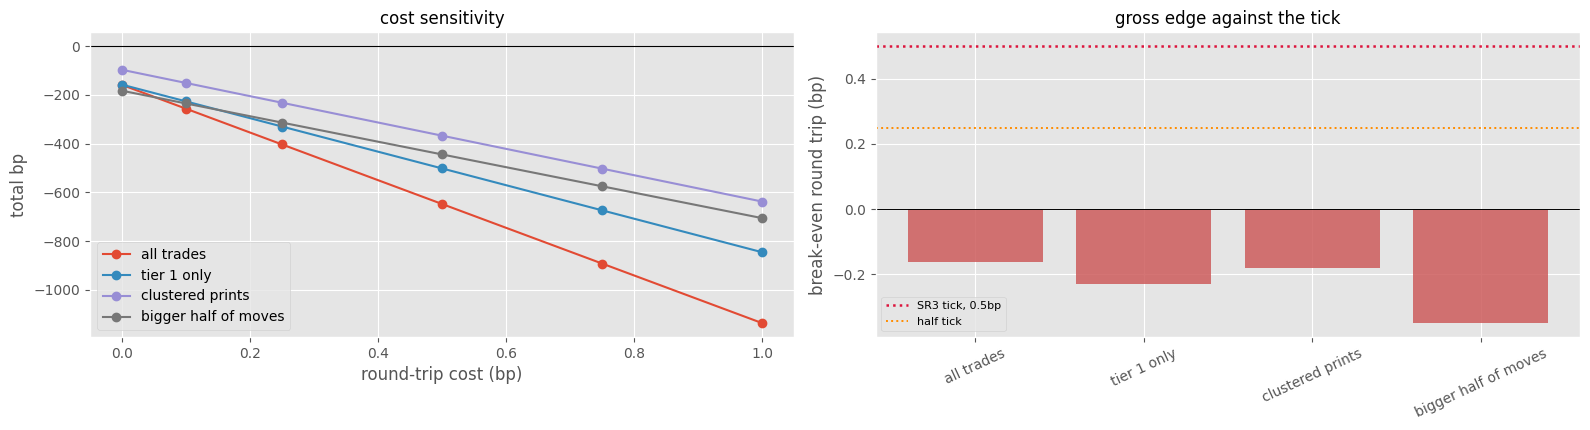

In [8]:
COSTS = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
books = {"all trades": CLOSED,
         "tier 1 only": CLOSED[CLOSED.impact == "high"],
         "clustered prints": CLOSED[CLOSED.n_events > 1],
         "bigger half of moves": CLOSED[CLOSED.abs_move_bp >= med]}
books = {k: v for k, v in books.items() if len(v) >= 20}

rows = []
for c in COSTS:
    r = {"cost_bp_rt": c}
    for nm, df in books.items():
        r[nm] = df.pnl_bp_gross.sum() - c * len(df)
    rows.append(r)
cost_df = pd.DataFrame(rows).set_index("cost_bp_rt")
display(cost_df.round(1))

be = {nm: df.pnl_bp_gross.mean() for nm, df in books.items()}
print("break-even round-trip cost (bp per unit of gross risk):")
for nm, v in sorted(be.items(), key=lambda x: -x[1]):
    verdict = ("clears an SR3 tick" if v >= 0.5 else
               "clears half a tick" if v >= 0.25 else
               "positive but under half a tick" if v > 0 else "NEGATIVE gross")
    print(f"  {nm:<24} {v:+.4f}   {verdict}")

fig, axes = plt.subplots(1, 2, figsize=(16, 4.4))
cost_df.plot(marker="o", ax=axes[0])
axes[0].axhline(0, color="k", lw=.8); axes[0].set_ylabel("total bp")
axes[0].set_xlabel("round-trip cost (bp)"); axes[0].set_title("cost sensitivity")
axes[1].bar(list(be), list(be.values()),
            color=["seagreen" if v > 0 else "indianred" for v in be.values()], alpha=.85)
axes[1].axhline(0.5, color="crimson", ls=":", lw=1.8, label="SR3 tick, 0.5bp")
axes[1].axhline(0.25, color="darkorange", ls=":", lw=1.4, label="half tick")
axes[1].axhline(0, color="k", lw=.7); axes[1].legend(fontsize=8)
axes[1].set_ylabel("break-even round trip (bp)"); axes[1].tick_params(axis="x", rotation=25)
axes[1].set_title("gross edge against the tick")
plt.tight_layout(); plt.show()

## 6. Which releases move the market

The per-title breakdown is where a "signal" most often turns out to be one or two prints, so the
trade-count column is there to be read first. A title appears on a row for every minute it printed
in, which for CPI means the minutes Core CPI also printed in — the two are inseparable by
construction, and §1.1 is why.

,trades,avg_bp,total_bp,hit,avg_move
titles,,,,,
Unemployment Claims,193,-0.1321,-25.5,0.4041,2.1891
Average Hourly Earnings m/m,78,-0.2628,-20.5,0.4615,5.4038
Non-Farm Employment Change,78,-0.2628,-20.5,0.4615,5.4038
Unemployment Rate,78,-0.2628,-20.5,0.4615,5.4038
Retail Sales m/m,68,-0.3088,-21.0,0.4559,2.0515
Core Retail Sales m/m,68,-0.3088,-21.0,0.4559,2.0515
Philly Fed Manufacturing Index,63,0.2222,14.0,0.4762,1.6746
CPI y/y,62,-0.5484,-34.0,0.4355,6.2661
CPI m/m,61,-0.5164,-31.5,0.4426,6.3852


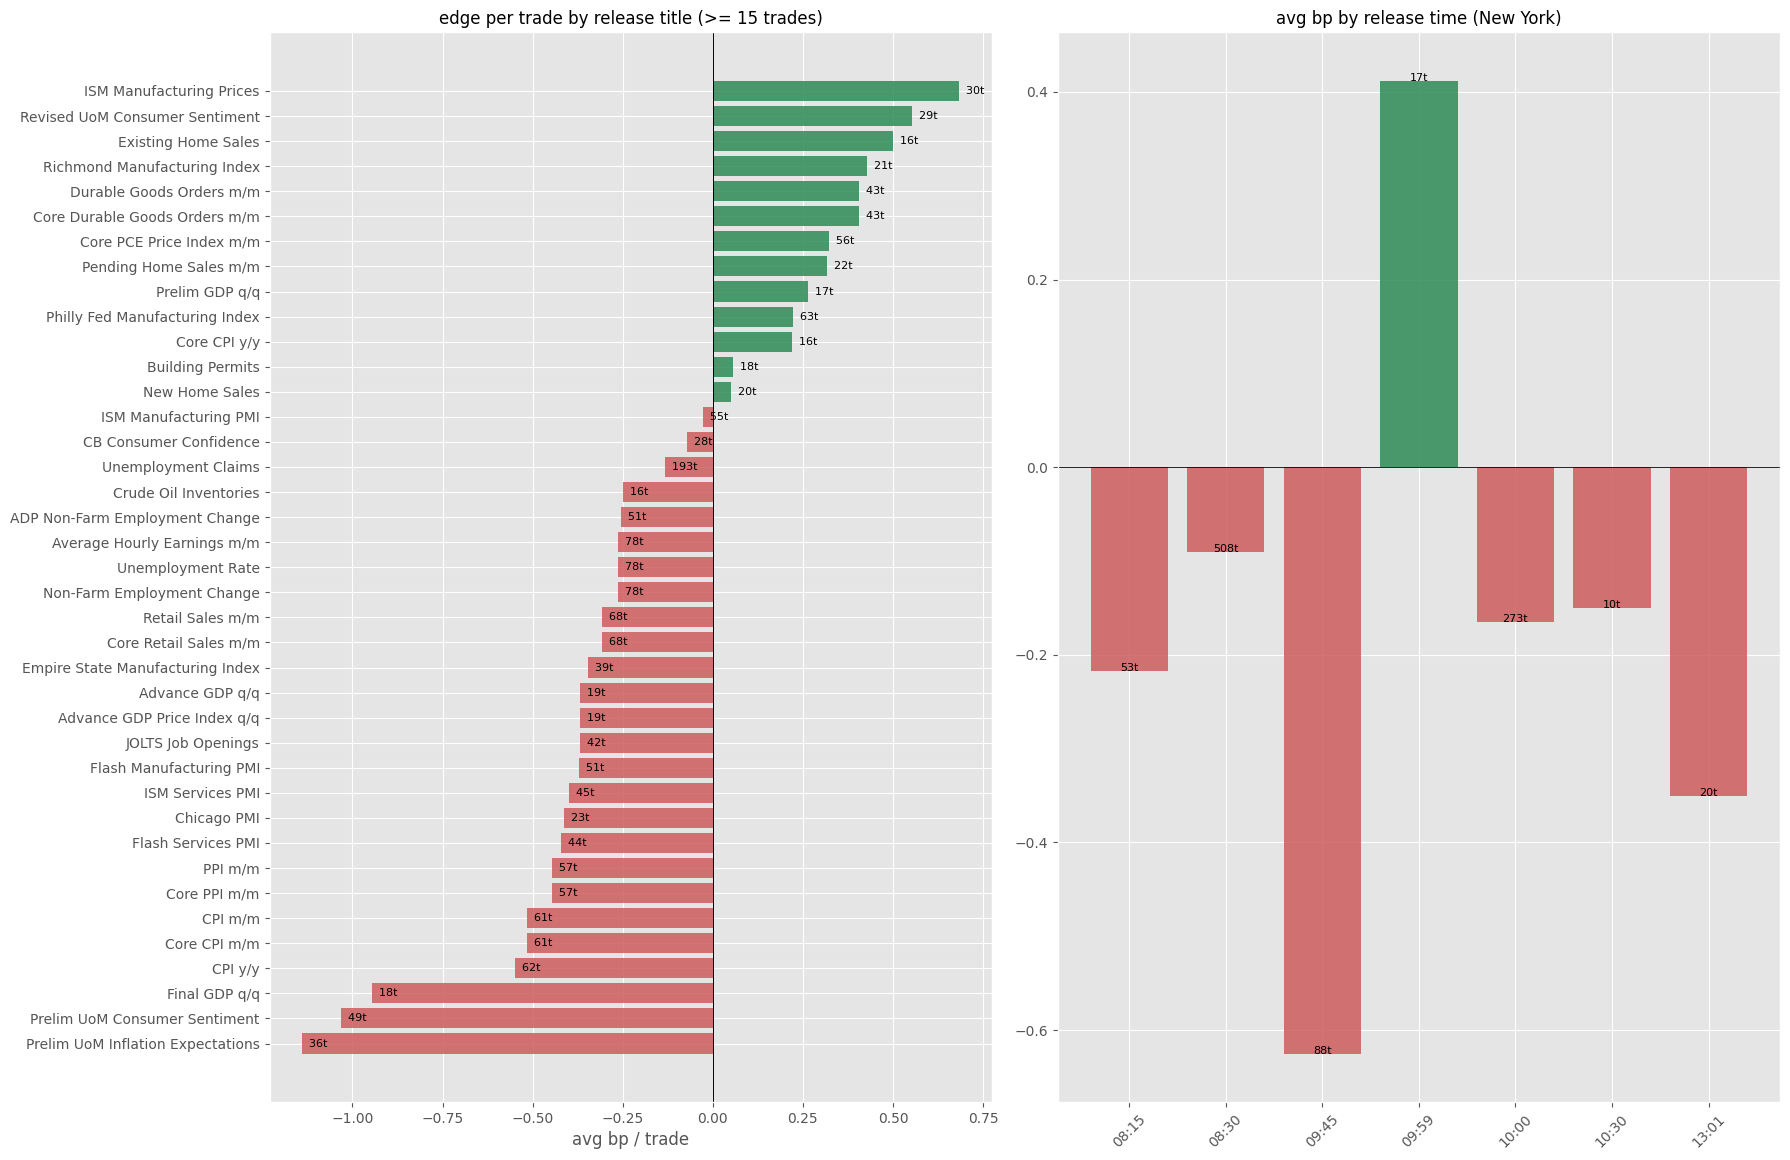

In [9]:
ex = CLOSED.explode("titles")
by = (ex.groupby("titles")
        .agg(trades=("pnl_bp", "size"), avg_bp=("pnl_bp", "mean"), total_bp=("pnl_bp", "sum"),
             hit=("profitable", "mean"), avg_move=("abs_move_bp", "mean"))
        .sort_values("trades", ascending=False))
display(by[by.trades >= 10].round(4).head(25))

top = by[by.trades >= 15].sort_values("avg_bp")
fig, axes = plt.subplots(1, 2, figsize=(18, max(4.5, .3 * len(top))))
axes[0].barh(top.index, top.avg_bp,
             color=["seagreen" if v > 0 else "indianred" for v in top.avg_bp], alpha=.85)
for i, (nm, r) in enumerate(top.iterrows()):
    axes[0].text(r.avg_bp, i, f"  {int(r.trades)}t", va="center", fontsize=8)
axes[0].axvline(0, color="k", lw=.7); axes[0].set_xlabel("avg bp / trade")
axes[0].set_title("edge per trade by release title (>= 15 trades)")

bt = CLOSED.groupby("release_time_ny").agg(avg=("pnl_bp", "mean"), n=("pnl_bp", "size"))
bt = bt[bt.n >= 10]
axes[1].bar(bt.index, bt["avg"],
            color=["seagreen" if v > 0 else "indianred" for v in bt["avg"]], alpha=.85)
for i, (nm, r) in enumerate(bt.iterrows()):
    axes[1].text(i, r["avg"], f"{int(r.n)}t", ha="center", fontsize=8)
axes[1].axhline(0, color="k", lw=.6); axes[1].set_title("avg bp by release time (New York)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 7. Does it scale with the size of the move?

If the first move is liquidity, a bigger burst should revert more — the edge ought to grow with
`|move|`. If it is information, a bigger burst should revert no more than a small one, and fading
the big ones should be the worst thing to do.

This is the closest thing here to a mechanism test, and it is the panel to look at before any
Sharpe.

,trades,avg_bp,gross_bp,hit,avg_move
abs_move_bp,,,,,
"(0.499999999999, 0.500000000001]",397,0.0907,0.0907,0.4081,0.5000
"(0.500000000001, 1.000000000001]",167,-0.1527,-0.1527,0.4431,1.0000
"(1.000000000001, 2.0]",129,-0.2054,-0.2054,0.4186,1.6860
"(2.0, 3.5]",128,-0.0820,-0.0820,0.4531,2.7148
"(3.5, 28.0]",157,-0.8439,-0.8439,0.4140,7.2803


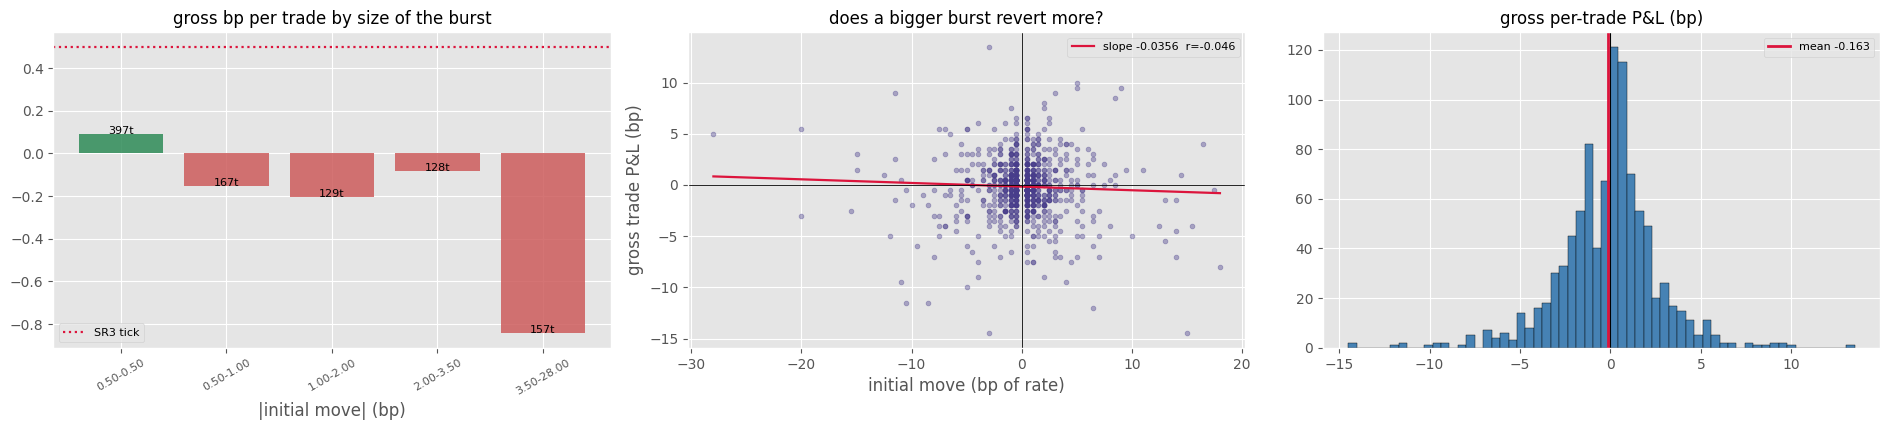

In [10]:
q = pd.qcut(CLOSED.abs_move_bp, min(6, CLOSED.abs_move_bp.nunique()), duplicates="drop")
byq = CLOSED.groupby(q, observed=True).agg(
    trades=("pnl_bp", "size"), avg_bp=("pnl_bp", "mean"), gross_bp=("pnl_bp_gross", "mean"),
    hit=("profitable", "mean"), avg_move=("abs_move_bp", "mean"))
display(byq.round(4))

fig, axes = plt.subplots(1, 3, figsize=(19, 4.4))
axes[0].bar(range(len(byq)), byq.gross_bp,
            color=["seagreen" if v > 0 else "indianred" for v in byq.gross_bp], alpha=.85)
axes[0].axhline(0.5, color="crimson", ls=":", lw=1.6, label="SR3 tick")
axes[0].set_xticks(range(len(byq)))
axes[0].set_xticklabels([f"{i.left:.2f}-{i.right:.2f}" for i in byq.index], rotation=30, fontsize=8)
for i, (nm, r) in enumerate(byq.iterrows()):
    axes[0].text(i, r.gross_bp, f"{int(r.trades)}t", ha="center", fontsize=8)
axes[0].legend(fontsize=8); axes[0].set_xlabel("|initial move| (bp)")
axes[0].set_title("gross bp per trade by size of the burst")

axes[1].scatter(CLOSED.move_bp, CLOSED.pnl_bp_gross, s=12, alpha=.4, color="darkslateblue")
if CLOSED.move_bp.std() > 0:
    b, a = np.polyfit(CLOSED.move_bp, CLOSED.pnl_bp_gross, 1)
    xs = np.linspace(CLOSED.move_bp.min(), CLOSED.move_bp.max(), 50)
    r_ = np.corrcoef(CLOSED.move_bp, CLOSED.pnl_bp_gross)[0, 1]
    axes[1].plot(xs, a + b * xs, color="crimson", lw=1.6, label=f"slope {b:+.4f}  r={r_:+.3f}")
    axes[1].legend(fontsize=8)
axes[1].axhline(0, color="k", lw=.6); axes[1].axvline(0, color="k", lw=.6)
axes[1].set_xlabel("initial move (bp of rate)"); axes[1].set_ylabel("gross trade P&L (bp)")
axes[1].set_title("does a bigger burst revert more?")

axes[2].hist(CLOSED.pnl_bp_gross, bins=60, color="steelblue", edgecolor="k", lw=.3)
axes[2].axvline(0, color="k", lw=.8)
axes[2].axvline(CLOSED.pnl_bp_gross.mean(), color="crimson", lw=2,
                label=f"mean {CLOSED.pnl_bp_gross.mean():+.3f}")
axes[2].legend(fontsize=8); axes[2].set_title("gross per-trade P&L (bp)")
plt.tight_layout(); plt.show()

## 8. How long should it be held?

Every horizon is priced from the same `get_data` calls the engine marks against, so the row at the
configured exit reproduces the engine run exactly — which is what makes the rest of the table mean
anything.

A fade that is real should decay: most of the reversion in the first minutes, then nothing. A curve
that keeps rising with the holding period is not a fade, it is a directional position that happens
to have been opened after a release.

,trades,total_bp,avg_bp,hit_rate,sr_per_trade,t_stat
hold_min,,,,,,
5,948,-94.0,-0.0992,0.3439,-0.0672,-2.0681
15,946,-100.0,-0.1057,0.3784,-0.0561,-1.7253
30,925,-135.0,-0.1459,0.4032,-0.0608,-1.8503
60,978,-159.0,-0.1626,0.4223,-0.0590,-1.8454
120,915,-125.5,-0.1372,0.4514,-0.0395,-1.1936
240,837,-257.0,-0.3070,0.4205,-0.0702,-2.0296


engine at T+60: -0.16258 bp/trade over 978 trades
table  at T+60: -0.16258 bp/trade over 978 trades


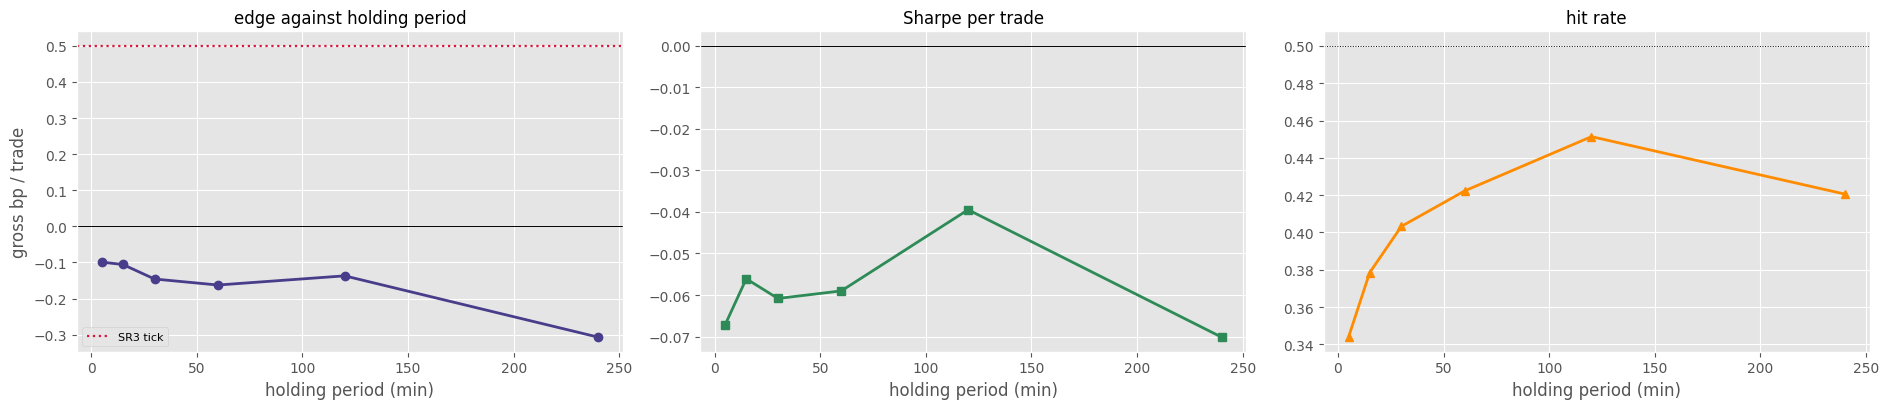

In [11]:
H = M.horizon_table(BOOK, CONFIG)
display(H.round(4))

cfg_h = CONFIG["timing"]["exit_offset_min"]
if cfg_h in H.index:
    print(f"engine at T+{cfg_h}: {CLOSED.pnl_bp_gross.mean():+.5f} bp/trade over {len(CLOSED)} trades")
    print(f"table  at T+{cfg_h}: {H.loc[cfg_h, 'avg_bp']:+.5f} bp/trade over "
          f"{int(H.loc[cfg_h, 'trades'])} trades")

fig, axes = plt.subplots(1, 3, figsize=(19, 4.2))
axes[0].plot(H.index, H.avg_bp, marker="o", lw=2, color="darkslateblue")
axes[0].axhline(0, color="k", lw=.7)
axes[0].axhline(0.5, color="crimson", ls=":", lw=1.6, label="SR3 tick")
axes[0].set_xlabel("holding period (min)"); axes[0].set_ylabel("gross bp / trade")
axes[0].set_title("edge against holding period"); axes[0].legend(fontsize=8)
axes[1].plot(H.index, H.sr_per_trade, marker="s", lw=2, color="seagreen")
axes[1].axhline(0, color="k", lw=.7); axes[1].set_xlabel("holding period (min)")
axes[1].set_title("Sharpe per trade")
axes[2].plot(H.index, H.hit_rate, marker="^", lw=2, color="darkorange")
axes[2].axhline(0.5, color="k", lw=.7, ls=":"); axes[2].set_xlabel("holding period (min)")
axes[2].set_title("hit rate")
plt.tight_layout(); plt.show()

## 9. Robustness

The sign-flip permutation randomises which way round each trade was taken while keeping the
magnitude distribution exactly. The null it tests is that the **direction** carried no information
— which is the strategy's actual claim — rather than the far weaker null that rates futures move.

sign-flip permutation — the null is that the DIRECTION carried nothing:
  realised -0.0590   null -0.0003 +- 0.0320   p = 0.0650


,trades,total_bp,avg_bp,hit,sharpe,range
half,,,,,,
1st half,489,-93.5,-0.1912,0.4274,-0.6457,2019-01-03 -> 2023-08-29
2nd half,489,-65.5,-0.1339,0.4172,-0.7069,2023-08-30 -> 2026-08-07


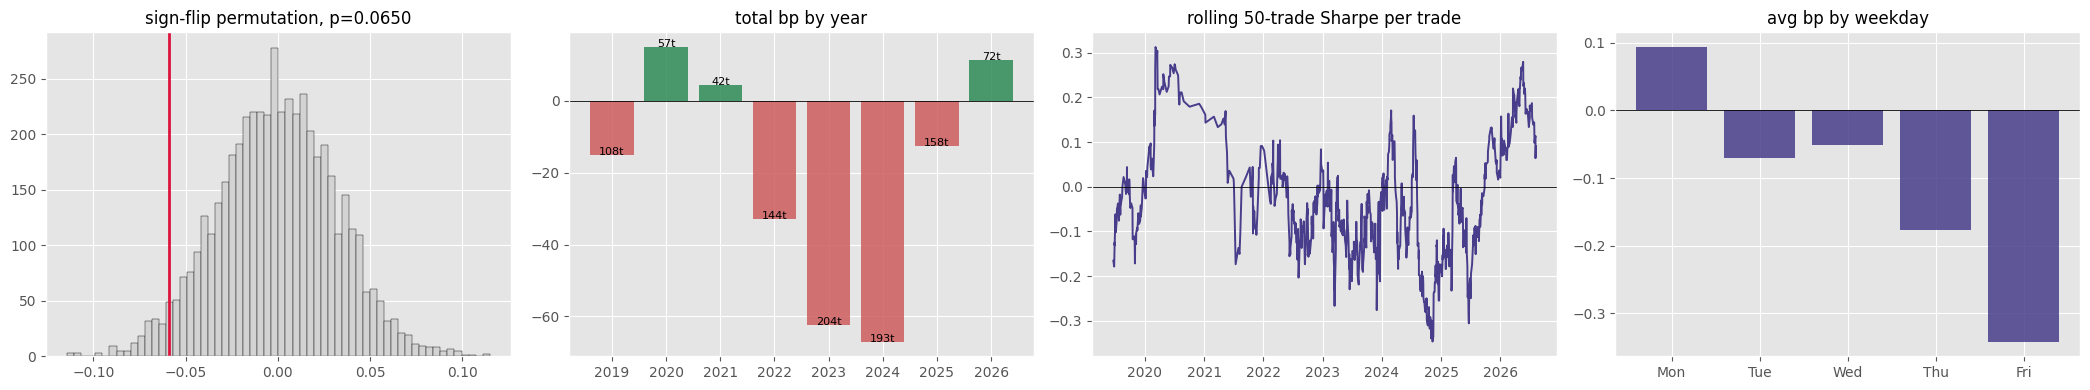

In [12]:
r = G.sign_flip_permutation(CLOSED, n_perm=5000)
print("sign-flip permutation — the null is that the DIRECTION carried nothing:")
print(f"  realised {r['realized_sharpe']:.4f}   null {r['perm_mean']:.4f} +- {r['perm_std']:.4f}"
      f"   p = {r['p_value']:.4f}")

mid = len(CLOSED) // 2
halves = []
for nm, sub in [("1st half", CLOSED.iloc[:mid]), ("2nd half", CLOSED.iloc[mid:])]:
    s = G.summarize(sub)
    halves.append({"half": nm, "trades": s["trades"], "total_bp": s["total_bp"],
                   "avg_bp": s["avg_bp"], "hit": s["hit_rate"], "sharpe": s["sharpe"],
                   "range": f"{pd.Timestamp(s['first']).date()} -> {pd.Timestamp(s['last']).date()}"})
display(pd.DataFrame(halves).set_index("half").round(4))

fig, axes = plt.subplots(1, 4, figsize=(21, 4))
axes[0].hist(r["perm"], bins=60, color="lightgrey", edgecolor="k", lw=.3)
axes[0].axvline(r["realized_sharpe"], color="crimson", lw=2)
axes[0].set_title(f"sign-flip permutation, p={r['p_value']:.4f}")

y = CLOSED.groupby("year").pnl_bp.agg(["sum", "size"])
axes[1].bar(y.index.astype(str), y["sum"],
            color=["seagreen" if v > 0 else "indianred" for v in y["sum"]], alpha=.85)
for i, (nm, rr) in enumerate(y.iterrows()):
    axes[1].text(i, rr["sum"], f"{int(rr['size'])}t", ha="center", fontsize=8)
axes[1].axhline(0, color="k", lw=.6); axes[1].set_title("total bp by year")

roll = CLOSED.pnl_bp.rolling(50)
axes[2].plot(CLOSED.release_ts.values, (roll.mean() / roll.std()).values,
             color="darkslateblue", lw=1.4)
axes[2].axhline(0, color="k", lw=.6); axes[2].set_title("rolling 50-trade Sharpe per trade")

w = CLOSED.groupby("weekday").pnl_bp.mean().reindex(["Mon", "Tue", "Wed", "Thu", "Fri"]).dropna()
axes[3].bar(w.index, w.values, color="darkslateblue", alpha=.85)
axes[3].axhline(0, color="k", lw=.6); axes[3].set_title("avg bp by weekday")
plt.tight_layout(); plt.show()

### 9.1 The comparison that matters

Two more engine runs, on the same machinery.

**Momentum** is the identical set of trades with the sign reversed. Gross of cost the two must be
near mirror images; if both make money the P&L is not coming from the direction of the initial move
and therefore not from the strategy.

**The wrong day** shifts every release timestamp forward one *business* day, onto a minute that had
no release. Business days, not calendar days: a calendar shift sends every Friday release to a
Saturday, and payrolls is a Friday release — the placebo would then differ because its sample
changed, not because the news went away. Time of day, contract, windows and the whole gate are
unchanged. 08:30 New York is also an hour before the cash equity open and the start of the most
liquid stretch of the session, so a mean-reversion effect that lives there every morning would show
up in §5 as a release effect and be nothing of the kind.

The placebo also answers a question the P&L cannot: **does the calendar mark anything at all?** An
event whose contract printed no new price between `T-1` and `T` is dropped as "moved nothing", and
the rate at which that happens is a direct measure of whether releases move the strip — measured on
variance rather than on direction, and therefore not contaminated by whether the fade works. It is
reported below next to the P&L, because the two can easily point opposite ways: a calendar can move
the market a great deal and still offer nothing to trade.

The placebo's book is smaller than the real one, and that is the finding rather than a defect: the
same gate keeps a much smaller share of wrong-day minutes precisely because fewer of them moved.

,trades,total_bp,avg_bp,hit,sharpe,t_stat,max_dd_bp
book,,,,,,,
THE REAL BOOK (fade),978,-159.0,-0.1626,0.4223,-0.6699,-1.8454,-201.5
momentum (sign flipped),978,159.0,0.1626,0.4540,0.6699,1.8454,-44.0
"wrong day, +1 business day",325,67.0,0.2062,0.4492,0.5065,1.3845,-37.5


fade + momentum on the 978 shared trades: mean +0.000000 bp, max |0.000000| bp
(the two books are the same trades with the sign reversed, so the pair must
 sum to zero exactly -- an offset here would be a marking bug, not a result)


,minutes priced,moved nothing,moved,move rate,mean |move| bp
book,,,,,
real releases,1390,412,978,0.7036,2.1201
wrong day +1bd,787,462,325,0.4130,0.5677


a release minute moves the strip 70.4% of the time; the same clock minute on a
day with no release moves it 41.3% of the time. THAT is the release effect --
and it is a statement about variance, not about the direction anything then takes.

real    -0.1626 bp/trade gross over 978 trades
placebo +0.2062 bp/trade gross over 325 trades
gap -0.3687 bp/trade   Mann-Whitney p = 0.1230
The GAP, not the real book's own mean, is the size of any release effect.


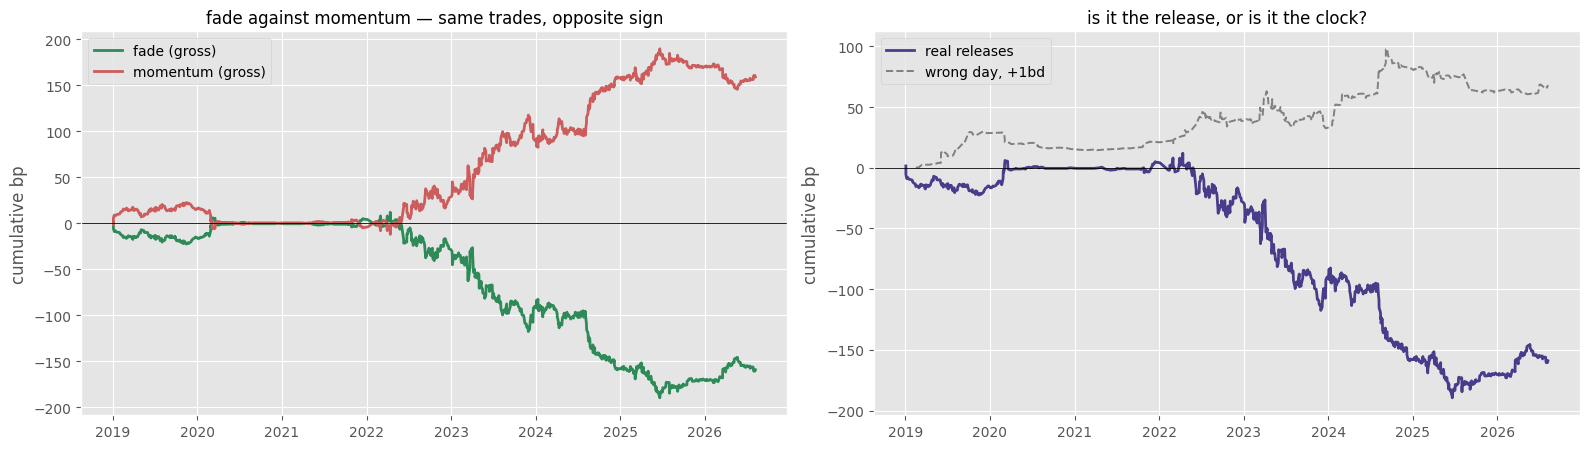

In [13]:
MOM_CFG = copy.deepcopy(CONFIG); MOM_CFG["name"] = "momentum"
MOM_CFG["signal"] = {**CONFIG["signal"], "direction": "momentum"}
MOM_BOOK, _ = M.build_book(RAW, MDP, MOM_CFG, show_progress=False)
MOM = M.run_engine(MOM_BOOK, MDP, MOM_CFG, show_progress=False)

RAW_P = C.placebo_shift(RAW, days=1)          # business day, real release minutes removed
PL_CFG = copy.deepcopy(CONFIG); PL_CFG["name"] = "wrong day +1bd"
PL_BOOK, PL_FUNNEL = M.build_book(RAW_P, MDP, PL_CFG, show_progress=False)
PLACEBO = M.run_engine(PL_BOOK, MDP, PL_CFG, show_progress=False)

rows = [perf(CLOSED, "THE REAL BOOK (fade)", "pnl_bp_gross"),
        perf(MOM, "momentum (sign flipped)", "pnl_bp_gross"),
        perf(PLACEBO, "wrong day, +1 business day", "pnl_bp_gross")]
display(pd.DataFrame(rows).set_index("book").round(4))

if len(MOM):
    # Join on (symbol, entry minute), NOT on tag -- the tag carries the config
    # name, so a fade tag and its own momentum twin never match and the check
    # would silently compare zero trades and report nan.
    key = ["symbol", "opened_at"]
    pair = (CLOSED[key + ["pnl_bp_gross"]]
            .merge(MOM[key + ["pnl_bp_gross"]], on=key, suffixes=("_fade", "_mom")))
    pair["sum"] = pair.pnl_bp_gross_fade + pair.pnl_bp_gross_mom
    print(f"fade + momentum on the {len(pair)} shared trades: "
          f"mean {pair['sum'].mean():+.6f} bp, max |{pair['sum'].abs().max():.6f}| bp")
    print("(the two books are the same trades with the sign reversed, so the pair must")
    print(" sum to zero exactly -- an offset here would be a marking bug, not a result)")

# THE result that is separate from profitability: does a release move the market
# at all? A minute in which the contract did not print a new price is dropped as
# "moved nothing", and the rate at which that happens is the cleanest measure of
# whether the calendar marks anything.
def move_rate(funnel):
    priced = funnel["gate"].get("priced", 0)
    flat = funnel.get("dropped: the release moved nothing", 0)
    return priced, flat, (priced - flat) / priced if priced else float("nan")

pr_r, fl_r, rate_r = move_rate(FUNNEL)
pr_p, fl_p, rate_p = move_rate(PL_FUNNEL)
display(pd.DataFrame([
    {"book": "real releases", "minutes priced": pr_r, "moved nothing": fl_r,
     "moved": pr_r - fl_r, "move rate": round(rate_r, 4),
     "mean |move| bp": round(BOOK.move_bp.abs().mean(), 4)},
    {"book": "wrong day +1bd", "minutes priced": pr_p, "moved nothing": fl_p,
     "moved": pr_p - fl_p, "move rate": round(rate_p, 4),
     "mean |move| bp": round(PL_BOOK.move_bp.abs().mean(), 4) if len(PL_BOOK) else np.nan},
]).set_index("book"))
print(f"a release minute moves the strip {rate_r:.1%} of the time; the same clock minute on a")
print(f"day with no release moves it {rate_p:.1%} of the time. THAT is the release effect --")
print("and it is a statement about variance, not about the direction anything then takes.")

if len(PLACEBO):
    print(f"\nreal    {CLOSED.pnl_bp_gross.mean():+.4f} bp/trade gross over {len(CLOSED)} trades")
    print(f"placebo {PLACEBO.pnl_bp_gross.mean():+.4f} bp/trade gross over {len(PLACEBO)} trades")
    gap = CLOSED.pnl_bp_gross.mean() - PLACEBO.pnl_bp_gross.mean()
    from scipy.stats import mannwhitneyu
    u = mannwhitneyu(CLOSED.pnl_bp_gross, PLACEBO.pnl_bp_gross, alternative="two-sided")
    print(f"gap {gap:+.4f} bp/trade   Mann-Whitney p = {u.pvalue:.4f}")
    print("The GAP, not the real book's own mean, is the size of any release effect.")
else:
    print("\nthe placebo book is empty -- its minutes were not primed into the MDP cache")

fig, axes = plt.subplots(1, 2, figsize=(16, 4.6))
axes[0].plot(CLOSED.release_ts.values, CLOSED.pnl_bp_gross.cumsum().values, lw=2,
             color="seagreen", label="fade (gross)")
if len(MOM):
    axes[0].plot(MOM.release_ts.values, MOM.pnl_bp_gross.cumsum().values, lw=2,
                 color="indianred", label="momentum (gross)")
axes[0].axhline(0, color="k", lw=.6); axes[0].legend(); axes[0].set_ylabel("cumulative bp")
axes[0].set_title("fade against momentum — same trades, opposite sign")
axes[1].plot(CLOSED.release_ts.values, CLOSED.pnl_bp_gross.cumsum().values, lw=2,
             color="darkslateblue", label="real releases")
if len(PLACEBO):
    axes[1].plot(PLACEBO.release_ts.values, PLACEBO.pnl_bp_gross.cumsum().values, lw=1.4,
                 ls="--", color="grey", label="wrong day, +1bd")
axes[1].axhline(0, color="k", lw=.6); axes[1].legend()
axes[1].set_title("is it the release, or is it the clock?"); axes[1].set_ylabel("cumulative bp")
plt.tight_layout(); plt.show()

## 10. Verdict

In [14]:
s = G.summarize(CLOSED)
gross = CLOSED.pnl_bp_gross.mean()
pl_mean = PLACEBO.pnl_bp_gross.mean() if len(PLACEBO) else float("nan")
verdict = {
    "provider": f"{type(MDP).__name__}(source={MDP.source!r}), fetcher disarmed",
    "engine": "QueryDrivenBacktest + STIRFutureHandler",
    "window": f"{CLOSED.release_ts.min().date()} -> {CLOSED.release_ts.max().date()}",
    "trades": s["trades"],
    "trades per year": round(s["trades_per_year"], 1),
    "gross bp / trade": round(gross, 5),
    "break-even round trip (bp)": round(gross, 5),
    "SR3 tick (bp)": 0.5,
    "clears one tick": bool(gross > 0.5),
    "hit rate": round(s["hit_rate"], 4),
    "annualised Sharpe (gross)": round(G.summarize(CLOSED, "pnl_bp_gross")["sharpe"], 4),
    "t-stat (gross)": round(G.summarize(CLOSED, "pnl_bp_gross")["t_stat"], 4),
    "sign-flip p": round(r["p_value"], 4),
    "wrong-day bp / trade": round(pl_mean, 5),
    "real minus wrong day": round(gross - pl_mean, 5) if pl_mean == pl_mean else None,
    "release minute moves the strip": f"{rate_r:.1%}",
    "wrong-day minute moves the strip": f"{rate_p:.1%}",
    "mean |initial move| bp": round(BOOK.move_bp.abs().mean(), 4),
}
display(pd.Series(verdict).to_frame("value"))

print()
if rate_r > rate_p + 0.05:
    print(f"The calendar marks something real: a release minute moves the strip {rate_r:.0%} of the")
    print(f"time against {rate_p:.0%} on the same clock minute of a day with no release.")
if gross <= 0:
    print(f"But the move does not come back. Fading it loses {gross:+.4f} bp per trade GROSS,")
    print("so the initial burst is, if anything, continued rather than reversed.")
elif gross <= 0.5:
    print(f"The gross edge of {gross:+.4f} bp does not clear one SR3 tick (0.5bp), so no")
    print("configuration of this idea is tradeable at the measured cost, whatever its t-statistic.")
if pl_mean == pl_mean and pl_mean >= gross:
    print("And a day with NO RELEASE pays at least as well, so nothing here is release-specific")
    print("beyond the extra variance.")

,value
provider,"STIRFutureMDP(source='BARCHART_STIRF-RL'), fet..."
engine,QueryDrivenBacktest + STIRFutureHandler
window,2019-01-03 -> 2026-08-07
trades,978
trades per year,128.9
gross bp / trade,-0.16258
break-even round trip (bp),-0.16258
SR3 tick (bp),0.5
clears one tick,False
hit rate,0.4223



The calendar marks something real: a release minute moves the strip 70% of the
time against 41% on the same clock minute of a day with no release.
But the move does not come back. Fading it loses -0.1626 bp per trade GROSS,
so the initial burst is, if anything, continued rather than reversed.
And a day with NO RELEASE pays at least as well, so nothing here is release-specific
beyond the extra variance.


## 11. Trade log

In [15]:
log = CLOSED[["release_ts", "opened_at", "closed_at", "lead_title", "n_events", "impact",
              "lead_outcome", "symbol", "side", "contracts", "move_bp", "pre_px", "post_px",
              "entry_px", "exit_px", "hold_min", "dv01_usd",
              "gross_realized_pnl", "pnl_bp_gross", "pnl_bp"]].copy()
log["cum_bp"] = log.pnl_bp.cumsum()
display(log.head(60).style.format({"pnl_bp": "{:+.3f}", "pnl_bp_gross": "{:+.3f}",
                                   "cum_bp": "{:+.2f}", "move_bp": "{:+.3f}",
                                   "gross_realized_pnl": "{:+,.2f}", "dv01_usd": "{:,.1f}"})
        .bar(subset=["pnl_bp"], color=["#d65f5f", "#5fba7d"], align="zero"))

out = G.CACHE / f"econ_fade_mdp_{CONFIG['name'].replace(' ', '_')}.csv"
log.to_csv(out, index=False)
pd.Series({**{"config": json.dumps(CONFIG, default=str)},
           **{k: str(v) for k, v in verdict.items()}}).to_frame("value").to_csv(
    G.CACHE / f"econ_fade_mdp_{CONFIG['name'].replace(' ', '_')}_verdict.csv")
print(f"wrote {out}  ({len(log)} trades)")

,release_ts,opened_at,closed_at,lead_title,n_events,impact,lead_outcome,symbol,side,contracts,move_bp,pre_px,post_px,entry_px,exit_px,hold_min,dv01_usd,gross_realized_pnl,pnl_bp_gross,pnl_bp,cum_bp
0,2019-01-03 13:15:00+00:00,2019-01-03 13:16:00+00:00,2019-01-03 14:15:00+00:00,ADP Non-Farm Employment Change,1,medium,better,GEU19,1.000000,1,+1.000,97.330000,97.320000,97.320000,97.335000,59.000000,25.0,+37.50,+1.500,+1.500,+1.50
1,2019-01-03 15:00:00+00:00,2019-01-03 15:01:00+00:00,2019-01-03 16:00:00+00:00,ISM Manufacturing PMI,1,high,worse,GEU19,-1.000000,1,-2.000,97.340000,97.360000,97.355000,97.425000,59.000000,25.0,-175.00,-7.000,-7.000,-5.50
2,2019-01-04 13:30:00+00:00,2019-01-04 13:31:00+00:00,2019-01-04 14:30:00+00:00,Unemployment Rate,3,high,worse,GEU19,1.000000,1,+5.500,97.410000,97.355000,97.365000,97.355000,59.000000,25.0,-25.00,-1.000,-1.000,-6.50
3,2019-01-07 15:00:00+00:00,2019-01-07 15:01:00+00:00,2019-01-07 16:00:00+00:00,ISM Services PMI,1,high,worse,GEU19,1.000000,1,+0.500,97.385000,97.380000,97.375000,97.350000,59.000000,25.0,-62.50,-2.500,-2.500,-9.00
4,2019-01-11 13:30:00+00:00,2019-01-11 13:31:00+00:00,2019-01-11 14:30:00+00:00,CPI m/m,4,high,none,GEU19,1.000000,1,+1.000,97.320000,97.310000,97.305000,97.315000,59.000000,25.0,+25.00,+1.000,+1.000,-8.00
5,2019-01-17 13:30:00+00:00,2019-01-17 13:31:00+00:00,2019-01-17 14:30:00+00:00,Philly Fed Manufacturing Index,1,medium,better,GEU19,1.000000,1,+0.500,97.310000,97.305000,97.300000,97.285000,59.000000,25.0,-37.50,-1.500,-1.500,-9.50
6,2019-01-29 15:00:00+00:00,2019-01-29 15:01:00+00:00,2019-01-29 16:00:00+00:00,CB Consumer Confidence,1,high,worse,GEU19,-1.000000,1,-0.500,97.285000,97.290000,97.290000,97.295000,59.000000,25.0,-12.50,-0.500,-0.500,-10.00
7,2019-01-31 14:45:00+00:00,2019-01-31 14:46:00+00:00,2019-01-31 15:45:00+00:00,Chicago PMI,1,medium,worse,GEU19,-1.000000,1,-0.500,97.365000,97.370000,97.365000,97.370000,59.000000,25.0,-12.50,-0.500,-0.500,-10.50
8,2019-02-01 13:30:00+00:00,2019-02-01 13:31:00+00:00,2019-02-01 14:30:00+00:00,Average Hourly Earnings m/m,3,high,worse,GEU19,1.000000,1,+0.500,97.390000,97.385000,97.375000,97.370000,59.000000,25.0,-12.50,-0.500,-0.500,-11.00
9,2019-02-01 15:00:00+00:00,2019-02-01 15:01:00+00:00,2019-02-01 16:00:00+00:00,ISM Manufacturing PMI,2,high,better,GEU19,1.000000,1,+1.000,97.375000,97.365000,97.360000,97.355000,59.000000,25.0,-12.50,-0.500,-0.500,-11.50


wrote C:\Users\chris\clee\ARBS-eco\notebooks\backtests\econ_release_fade\_cache\econ_fade_mdp_mdp-baseline.csv  (978 trades)
